# 06_09 - Fig. 4C group-size analysis on the DEPTH-MATCHED arm


In [27]:
# relocation-proof bootstrap
import os
import sys

_d = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_d, '.notebooks_root')):
    _p = os.path.dirname(_d)
    if _p == _d:
        raise RuntimeError('could not locate .notebooks_root above this notebook')
    _d = _p
os.chdir(_d)
if _d not in sys.path:
    sys.path.insert(0, _d)
print('working dir:', os.getcwd())

import gc
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.sparse import issparse, csr_matrix
import matplotlib
import matplotlib.pyplot as plt

import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath
import senescence_robustness as sr
importlib.reload(sr)

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.width', 240)

working dir: /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks


In [28]:
# preferred plot formatting
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0
plt.rcParams.update({
    'font.size': 6, 'axes.titlesize': 6, 'axes.labelsize': 6,
    'xtick.labelsize': 6, 'ytick.labelsize': 6,
    'legend.fontsize': 6, 'legend.title_fontsize': 6,
    'legend.labelspacing': 0.1, 'legend.borderpad': 0.3, 'legend.handletextpad': 0.2,
    'figure.titlesize': 6,
    'axes.labelweight': 'bold', 'axes.titleweight': 'bold', 'figure.titleweight': 'bold',
    'xtick.major.size': TICK_LEN, 'ytick.major.size': TICK_LEN,
    'xtick.major.pad': TICK_LABEL_PAD, 'ytick.major.pad': TICK_LABEL_PAD,
    'axes.labelpad': AXIS_LABEL_PAD,
})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'
matplotlib.rcParams['mathtext.cal'] = 'Arial:italic'
matplotlib.rcParams['mathtext.sf'] = 'Arial'
matplotlib.rcParams['mathtext.tt'] = 'Arial'

SEN_COLOR = '#c44e52'
NON_COLOR = '#4c72b0'
DONOR_PALETTE = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860']

H5AD_DIR = '../pacbio/h5ads'
CSV_DIR = '../csvs'
OUT = CSV_DIR + '/06_36_robustness'
os.makedirs(OUT, exist_ok=True)
# NOT the _with_isofrac object: that one is pre-filtered to isoforms in >=10 cells
# and genes with >=2 isoforms, which is itself a richness filter and would bias
# exactly the quantity under study.
OBJ = (H5AD_DIR + '/all_samples_pacbio_recollapsed_raw_counts_ensemblids'
       '_bc_anndata_preprocessed_xgen_cdkn2a.h5ad')
STATUS_COL = 'xgen_cdkn2a_raw_status'
DEPTH = 'total_counts'

# --- DEPTH CONTROL: 1:1 MATCHING, NOT STRATIFICATION ------------------------
# Matching is applied once, at load, so every count below is on the matched
# cells. DEPTH_N_BINS then stays 1 by design: the arms already share a depth
# distribution, so stratified_unit_effects is a plain per-tube difference of
# means and rarefy_reference_mask a pure group-size match. Re-stratifying
# inside the matched arm would only thin the per-block cells and buy nothing.
DEPTH_CORRECTION = False      # no stratification -- matching replaces it
DEPTH_N_BINS = 10 if DEPTH_CORRECTION else 1
DEPTH_MATCH = True            # False reproduces the deleted no-depth arm
# MATCH_WITHIN nests the match inside the sample: bins become quantiles OF
# THAT TUBE and pairing happens inside (tube x bin). None = pooled match, which
# balances depth only marginally because tubes differ several-fold in depth.
# A string names one obs column; a LIST nests on the composite key.
# ⚠ NESTING DEPTH. (tube_id x broad_cell_class) is a MUCH finer grouping than tube_id
# alone: ~50 tubes x ~34 classes is up to ~1,700 groups, and MATCH_BINS quantiles are
# recomputed inside each. A block contributes only if it holds BOTH arms, so senescent
# cells in thin (tube, class) combinations are dropped. Check the retention print below
# before quoting anything: if it falls far, lower MATCH_BINS (3-5 is reasonable at this
# nesting) rather than accepting a biased survivor set.
MATCH_WITHIN = ['tube_id']
MATCH_BINS = 20               # depth bins for the 1:1 match, as in 06_55/06_57
                              # NOTE: with MATCH_WITHIN set these are PER TUBE,
                              # so 20 is far finer than it was pooled. Thin
                              # blocks drop senescent cells -- watch retention.
MATCH_SEED = 0
N_REPEATS = 20
MIN_PER_STRATUM = 5        # cells per arm per (tube x depth stratum)
SEED = 0
final = {}

## 1. The problem, quantified


In [29]:
import scanpy as sc
adata = sc.read_h5ad(OBJ)
st = adata.obs[STATUS_COL].astype(str)
adata = adata[(~st.isin(['other_CDKN2A+', 'p14ARF+'])).values].copy()
st = adata.obs[STATUS_COL].astype(str)
adata.obs['is_senescent'] = st.isin(['p16+', 'Both']).values
print(f'{adata.n_obs:,} cells x {adata.n_vars:,} isoforms (before depth matching)')

# ---------------------------------------------------------------- DEPTH MATCHING
# Keeps EVERY senescent cell and draws an equal number of reference cells from the same depth
# bin, so the arms share a depth distribution bin by bin. It changes WHICH cells are compared,
# never what is inside them: no count is altered and no sampling noise is added. Applied here,
# before any isoform is counted, so every number and figure below is on the matched arm.
if DEPTH_MATCH:
    _sen0 = adata.obs['is_senescent'].values
    _depth0 = adata.obs[DEPTH].values
    if MATCH_WITHIN:
        # matched_indices_by_block, not depth_matched_indices: the latter keeps
        # the minority arm WHOLE and only subsamples the majority. Pooled that
        # never bound (the reference arm always had spare cells at every depth,
        # which is why the pooled run came out exactly 3,134 vs 3,134), but a
        # single tube's block can hold more senescent than reference cells, and
        # unequal arms would void the equal-n premise of every count below.
        _cols0 = ([MATCH_WITHIN] if isinstance(MATCH_WITHIN, str)
                  else list(MATCH_WITHIN))
        _missing = [c for c in _cols0 if c not in adata.obs.columns]
        assert not _missing, f'MATCH_WITHIN columns not in obs: {_missing}'
        _u0 = adata.obs[_cols0[0]].astype(str)
        for _c0 in _cols0[1:]:
            _u0 = _u0.str.cat(adata.obs[_c0].astype(str), sep='||')
        _unit0 = _u0.values
        print(f'matching nested on {" x ".join(_cols0)}  '
              f'({len(pd.unique(_unit0)):,} groups)')
        _dbw = sr.depth_bin_within(_depth0, _unit0, n_bins=MATCH_BINS)
        _blk = np.array([u + '|' + str(b) for u, b in zip(_unit0, _dbw)])
        _mi, _mj = sr.matched_indices_by_block(_sen0, _blk, seed=MATCH_SEED,
                                               ratio=1)
    else:
        _mi, _mj = sr.depth_matched_indices(_depth0, _sen0, n_bins=MATCH_BINS,
                                            seed=MATCH_SEED, ratio=1)
    idx_m = np.sort(np.concatenate([_mi, _mj]))
    _n0, _s0 = adata.n_obs, int(_sen0.sum())
    adata = adata[idx_m].copy()
    _senm = adata.obs['is_senescent'].values
    print(f'depth-matched: {adata.n_obs:,} of {_n0:,} cells '
          f'({100 * adata.n_obs / _n0:.1f}%), '
          f'{int(_senm.sum()):,} senescent + {int((~_senm).sum()):,} reference')
    _drop = _s0 - int(_senm.sum())
    if _drop:
        print(f'  NOTE: {_drop:,} senescent cells dropped ({100 * _drop / _s0:.1f}%) -- their')
        print('  ' + ('(tube x depth bin) block' if MATCH_WITHIN else 'depth bin')
              + ' held no reference cell, so no pair could be formed.')
        print('  The survivors are a BIASED subset -- they sit where reference cells')
        print('  exist -- so quote retention alongside the ratio.')
    print(f"  Cliff's delta on depth  BEFORE "
          f"{sr.cliffs_delta(_depth0[_sen0], _depth0[~_sen0]):+.3f}   AFTER "
          f"{sr.cliffs_delta(adata.obs[DEPTH].values[_senm], adata.obs[DEPTH].values[~_senm]):+.3f}")
    final['n_cells_matched'] = int(adata.n_obs)
    final['depth_control'] = (f'1:1 matched, {MATCH_BINS} bins, seed {MATCH_SEED}'
                              + (', within ' + ' x '.join(_cols0) if MATCH_WITHIN
                                 else ', pooled'))
    final['n_sen_retained_frac'] = float(int(_senm.sum()) / _s0)
    if MATCH_WITHIN:
        _u = adata.obs[_cols0[0]].astype(str)
        for _c0 in _cols0[1:]:
            _u = _u.str.cat(adata.obs[_c0].astype(str), sep='||')
        _u = _u.values
        print(f'  groups contributing: {len(np.unique(_u)):,}')
        final['n_units_contributing'] = int(len(np.unique(_u)))
else:
    print('DEPTH_MATCH is False -- NO depth control at all, the behaviour of the')
    print('deleted 06_45b. Every number below is then depth-confounded.')
    final['depth_control'] = 'none'

X = adata.X.tocsr() if issparse(adata.X) else csr_matrix(adata.X)
Xb = X.copy()
Xb.data = np.ones_like(Xb.data)          # presence/absence
grp = adata.obs['is_senescent'].values
i_sen = np.where(grp)[0]
i_non = np.where(~grp)[0]
n_sen, n_non = len(i_sen), len(i_non)

def n_detected(rows):
    return int((np.asarray(Xb[rows].sum(axis=0)).ravel() > 0).sum())

det_sen_full = n_detected(i_sen)
det_non_full = n_detected(i_non)
print()
print('AS PUBLISHED (all cells in each arm)')
print(f'  senescent      : {n_sen:,} cells -> {det_sen_full:,} isoforms detected')
print(f'  non-senescent  : {n_non:,} cells -> {det_non_full:,} isoforms detected')
print(f'  ratio of cell counts     : {n_non / n_sen:.1f}x')
print(f'  ratio of isoform counts  : {det_non_full / det_sen_full:.1f}x')
print()
print('The second ratio is what Fig. 5C reports. The first is why.')
final['n_sen'] = n_sen
final['n_non'] = n_non
final['detected_sen_full'] = det_sen_full
final['detected_non_full'] = det_non_full

154,182 cells x 489,842 isoforms (before depth matching)
matching nested on tube_id  (50 groups)
depth-matched: 5,862 of 154,182 cells (3.8%), 2,931 senescent + 2,931 reference
  NOTE: 203 senescent cells dropped (6.5%) -- their
  (tube x depth bin) block held no reference cell, so no pair could be formed.
  The survivors are a BIASED subset -- they sit where reference cells
  exist -- so quote retention alongside the ratio.
  Cliff's delta on depth  BEFORE +0.550   AFTER +0.024
  groups contributing: 47

AS PUBLISHED (all cells in each arm)
  senescent      : 2,931 cells -> 313,691 isoforms detected
  non-senescent  : 2,931 cells -> 307,454 isoforms detected
  ratio of cell counts     : 1.0x
  ratio of isoform counts  : 1.0x

The second ratio is what Fig. 5C reports. The first is why.


In [30]:
# SQANTI3 structural category is NOT stored in the h5ad -- the project loads it at
# runtime, not baked
# into h5ads"). Fig. 5C is coloured by it, so the replacement panel needs it merged.
# NOTE sep=',' : the project's classification CSVs are comma-separated while the
# helper defaults to TSV, and a wrong separator yields one giant unusable column.
from add_classification import add_classification

CLASS_CSV = CSV_DIR + '/all_samples_recollapsed_sqanti3_classification_ensemblids.csv'
if not os.path.exists(CLASS_CSV):
    print('MISSING ' + CLASS_CSV)
    print('-> the structural-category breakdown in Section 3 will collapse to "all"')
else:
    _before = set(adata.var.columns)
    add_classification(adata, CLASS_CSV, sep=',')
    _added = sorted(set(adata.var.columns) - _before)
    print(f'merged {len(_added)} columns into var, including: '
          f'{[c for c in _added if "structural" in c or "category" in c]}')
    if 'structural_category' in adata.var.columns:
        _ok = adata.var['structural_category'].notna()
        print(f'annotated: {int(_ok.sum()):,} of {adata.n_vars:,} isoforms '
              f'({100 * _ok.mean():.1f}%)')
        print()
        print(adata.var.loc[_ok, 'structural_category'].value_counts().to_string())
        if _ok.mean() < 0.9:
            print()
            print(f'WARNING: {100 * (1 - _ok.mean()):.1f}% of isoforms are unannotated.')
            print('They are reported as a separate "unannotated" bar rather than')
            print('dropped, so the category totals still sum to the overall count.')

merged 15 columns into var, including: ['structural_category', 'subcategory']
annotated: 470,340 of 489,842 isoforms (96.0%)

structural_category
novel_not_in_catalog       189741
novel_in_catalog           130627
incomplete-splice_match     71611
full-splice_match           66143
fusion                       7225
genic                        4746
genic_intron                  101
antisense                      98
intergenic                     48


## 2. Rarefaction curves


In [31]:
rng = np.random.default_rng(SEED)
ks = np.unique(np.round(np.logspace(np.log10(25), np.log10(n_sen), 14)).astype(int))
ks_non = np.unique(np.concatenate([ks, np.round(np.logspace(
    np.log10(n_sen), np.log10(n_non), 6)).astype(int)]))

rows = []
for label, idx, kgrid in [('senescent', i_sen, ks), ('non-senescent', i_non, ks_non)]:
    for k in kgrid:
        if k > len(idx):
            continue
        vals = [n_detected(rng.choice(idx, k, replace=False)) for _ in range(N_REPEATS)]
        rows.append({'group': label, 'n_cells': int(k),
                     'mean_detected': float(np.mean(vals)),
                     'sd_detected': float(np.std(vals))})
rare = pd.DataFrame(rows)
rare.to_csv(OUT + '/06_09_rarefaction_curves.csv', index=False)

at_k = rare[rare.n_cells == ks[-1]].set_index('group')
print(f'at n = {ks[-1]:,} cells in BOTH arms:')
print(at_k[['mean_detected', 'sd_detected']].round(1).to_string())
d_sen = at_k.loc['senescent', 'mean_detected']
d_non = at_k.loc['non-senescent', 'mean_detected']
print()
print(f'  senescent / non-senescent at matched n: {d_sen / d_non:.3f}')
print(f'  (published ratio, unmatched n:          {det_sen_full / det_non_full:.3f})')
final['matched_n'] = int(ks[-1])
final['detected_sen_at_matched_n'] = float(d_sen)
final['detected_non_at_matched_n'] = float(d_non)
final['ratio_matched'] = float(d_sen / d_non)
final['ratio_published'] = float(det_sen_full / det_non_full)

at n = 2,931 cells in BOTH arms:
               mean_detected  sd_detected
group                                    
senescent           313691.0          0.0
non-senescent       307454.0          0.0

  senescent / non-senescent at matched n: 1.020
  (published ratio, unmatched n:          1.020)


## 3. Equal-n comparison, overall and by structural category


In [32]:
cat_col = next((c for c in ('structural_category', 'pigeon_structural_category',
                           'sqanti_structural_category')
                if c in adata.var.columns), None)
print('structural category column:', cat_col)
sub_col = next((c for c in ('subcategory', 'pigeon_subcategory', 'sqanti_subcategory')
                if c in adata.var.columns), None)
print('structural subcategory column:', sub_col)

def detected_by(rows, col):
    """Isoforms detected by `rows`, split by adata.var[col]. col=None -> total only."""
    hit = np.asarray(Xb[rows].sum(axis=0)).ravel() > 0
    if col is None:
        return {'all': int(hit.sum())}
    cats = adata.var[col].astype(str).values
    # NaN -> 'unannotated' rather than the string 'nan', so the bar is
    # interpretable and the categories still sum to the overall total
    cats = np.where(pd.isna(adata.var[col].values), 'unannotated', cats)
    out = {'all': int(hit.sum())}
    for c in np.unique(cats):
        out[c] = int((hit & (cats == c)).sum())
    return out


def detected_by_cat(rows):
    return detected_by(rows, cat_col)

# NOTE, once DEPTH_MATCH is on: matching is 1:1, so the two arms already hold the same number
# of cells and rng.choice(i_non, n_sen) draws the WHOLE reference arm every repeat. The equal-n
# control is therefore a no-op here -- non_sen_equal_n_mean equals non_sen_ALL_cells exactly and
# the sd is 0, which is correct, not a bug. It also means z_equal_n is NaN and the N_REPEATS
# loop is redundant; both are kept rather than deleted, so the control is visible.
sen_counts = detected_by_cat(i_sen)
sen_counts_sub = detected_by(i_sen, sub_col)
rows, rows_sub = [], []
# ONE rng.choice per repeat, scored under BOTH breakdowns. Drawing separately would give
# the subcategory panel different reference subsamples from the category panel and make the
# two non-comparable, and it would change the category numbers as well.
for rep in range(N_REPEATS):
    sub_non = rng.choice(i_non, n_sen, replace=False)
    d = detected_by_cat(sub_non); d['repeat'] = rep; rows.append(d)
    ds = detected_by(sub_non, sub_col); ds['repeat'] = rep; rows_sub.append(ds)
non_eq = pd.DataFrame(rows)
non_eq_sub = pd.DataFrame(rows_sub)
cats = [c for c in non_eq.columns if c != 'repeat']

summary = pd.DataFrame({
    'senescent': pd.Series(sen_counts),
    'non_sen_equal_n_mean': non_eq[cats].mean(),
    'non_sen_equal_n_sd': non_eq[cats].std(),
    'non_sen_ALL_cells': pd.Series(detected_by_cat(i_non)),
}).loc[cats]
summary['ratio_equal_n'] = summary['senescent'] / summary['non_sen_equal_n_mean']
summary['ratio_published'] = summary['senescent'] / summary['non_sen_ALL_cells']
summary['z_equal_n'] = ((summary['senescent'] - summary['non_sen_equal_n_mean'])
                        / summary['non_sen_equal_n_sd'].replace(0, np.nan))
summary.to_csv(OUT + '/06_09_equal_n_by_category.csv')
print(summary.round(3).to_string())
print()
_r = summary.loc['all', 'ratio_equal_n']
print(f"OVERALL at equal n: senescent detects {_r:.2f}x the non-senescent arm")
print(f"  published (unmatched): {summary.loc['all', 'ratio_published']:.2f}x")
if _r > 1:
    print('  DIRECTION REVERSES at equal n -- the published claim that senescent')
    print('  cells contain FEWER isoforms is a group-size artifact and must be')
    print('  withdrawn or restated.')
else:
    print('  Direction is preserved at equal n -- the claim survives, but the')
    print('  magnitude in Fig. 5C is inflated and the "despite representing only a')
    print('  small fraction of cells" framing is still wrong.')
final['equal_n_ratio_all'] = float(_r)

# --- the same comparison, by structural SUBcategory ---------------------------------------
if sub_col is None:
    summary_sub = None
    print('\nNo subcategory column in adata.var -- subcategory panel skipped.')
else:
    cats_sub = [c for c in non_eq_sub.columns if c != 'repeat']
    summary_sub = pd.DataFrame({
        'senescent': pd.Series(sen_counts_sub),
        'non_sen_equal_n_mean': non_eq_sub[cats_sub].mean(),
        'non_sen_equal_n_sd': non_eq_sub[cats_sub].std(),
        'non_sen_ALL_cells': pd.Series(detected_by(i_non, sub_col)),
    }).loc[cats_sub]
    summary_sub['ratio_equal_n'] = (summary_sub['senescent']
                                    / summary_sub['non_sen_equal_n_mean'])
    summary_sub['ratio_published'] = (summary_sub['senescent']
                                      / summary_sub['non_sen_ALL_cells'])
    summary_sub['z_equal_n'] = ((summary_sub['senescent']
                                 - summary_sub['non_sen_equal_n_mean'])
                                / summary_sub['non_sen_equal_n_sd'].replace(0, np.nan))
    summary_sub.to_csv(OUT + '/06_09_equal_n_by_subcategory.csv')
    print(f'\nBy structural subcategory ({len(cats_sub) - 1} levels):')
    print(summary_sub.round(3).to_string())
    # 'all' is identical in both tables -- the split changes, not the population.
    assert (int(summary_sub.loc['all', 'senescent'])
            == int(summary.loc['all', 'senescent'])), (
        'subcategory total disagrees with the category total')

structural category column: structural_category
structural subcategory column: subcategory
                         senescent  non_sen_equal_n_mean  non_sen_equal_n_sd  non_sen_ALL_cells  ratio_equal_n  ratio_published  z_equal_n
all                         313691              307454.0                 0.0             307454          1.020            1.020        NaN
antisense                       60                  61.0                 0.0                 61          0.984            0.984        NaN
full-splice_match            54239               53991.0                 0.0              53991          1.005            1.005        NaN
fusion                        4305                4127.0                 0.0               4127          1.043            1.043        NaN
genic                         3321                3197.0                 0.0               3197          1.039            1.039        NaN
genic_intron                    42                  37.0                 0.

## 4. Controlling group size and depth together


In [33]:
tube = adata.obs['tube_id'].astype(str).values
dbin = sr.depth_bin(adata.obs[DEPTH].values, n_bins=DEPTH_N_BINS)
if not DEPTH_CORRECTION:
    assert len(np.unique(dbin)) == 1, 'expected a single stratum'
    print('DEPTH CORRECTION OFF: one stratum, so the row below is a GROUP-SIZE')
    print('match within tube, not a depth control. The depth control in this')
    print('notebook is the 1:1 within-tube match applied at load (Section 1);')
    print('The stratified alternative (the deleted 06_09) is no longer computed.')
rows = []
for rep in range(N_REPEATS):
    # unit=tube, not a constant: blocks the group-size match on the sample, to
    # match the within-tube design of the depth match at load.
    keep = sr.rarefy_reference_mask(grp, tube, dbin, seed=rep)
    a = np.where(keep & grp)[0]
    b = np.where(keep & ~grp)[0]
    rows.append({'repeat': rep, 'n_sen': len(a), 'n_non': len(b),
                 'detected_sen': n_detected(a), 'detected_non': n_detected(b)})
dm = pd.DataFrame(rows)
dm['ratio'] = dm.detected_sen / dm.detected_non
dm.to_csv(OUT + '/06_09_depth_and_n_matched.csv', index=False)
print(dm.round(3).to_string(index=False))
print()
print(f'n-matched ratio (NO depth control): {dm.ratio.mean():.3f} '
      f'+/- {dm.ratio.std():.3f}')
print(f'  n-matched only  : {final["equal_n_ratio_all"]:.3f}')
print(f'  published       : {final["ratio_published"]:.3f}')
print()
print('Reading: with depth blocking off this removes GROUP SIZE only, within')
print('tube. On a balanced within-tube matched arm it should change nothing;')
print('if it does, the match at load did not balance the tubes it claims to.')
print('The stratified alternative that used to sit in 06_09 is gone as of')
print('2026-08-21; see senescence_robustness.stratified_unit_effects to rebuild it.')
final['depth_n_matched_ratio'] = float(dm.ratio.mean())
final['depth_n_matched_sd'] = float(dm.ratio.std())

DEPTH CORRECTION OFF: one stratum, so the row below is a GROUP-SIZE
match within tube, not a depth control. The depth control in this
notebook is the 1:1 within-tube match applied at load (Section 1);
The stratified alternative (the deleted 06_09) is no longer computed.
 repeat  n_sen  n_non  detected_sen  detected_non  ratio
      0   2931   2931        313691        307454   1.02
      1   2931   2931        313691        307454   1.02
      2   2931   2931        313691        307454   1.02
      3   2931   2931        313691        307454   1.02
      4   2931   2931        313691        307454   1.02
      5   2931   2931        313691        307454   1.02
      6   2931   2931        313691        307454   1.02
      7   2931   2931        313691        307454   1.02
      8   2931   2931        313691        307454   1.02
      9   2931   2931        313691        307454   1.02
     10   2931   2931        313691        307454   1.02
     11   2931   2931        313691        30

## 5. An n-independent alternative: isoforms per cell


In [34]:
iso_per_cell = np.asarray(Xb.sum(axis=1)).ravel()
tube = adata.obs['tube_id'].astype(str).values
donor = adata.obs['donor'].astype(str).values
tube_eff = sr.stratified_unit_effects(iso_per_cell, grp, tube, dbin,
                                      min_per_stratum=MIN_PER_STRATUM, unit_name='tube_id')
t2d = pd.Series(donor, index=pd.Index(tube)).groupby(level=0).first()
tube_eff['donor'] = tube_eff['tube_id'].map(t2d)
ok = tube_eff.dropna(subset=['effect'])
flat = sr.dersimonian_laird(tube_eff['effect'].values, tube_eff['se'].values)
nested, per_donor = sr.nested_meta_analysis(tube_eff['effect'].values,
                                            tube_eff['se'].values,
                                            tube_eff['donor'].values)
tube_eff.to_csv(OUT + '/06_09_isoforms_per_cell_by_sample.csv', index=False)
print(f'isoforms per cell: senescent median {np.median(iso_per_cell[grp]):.0f}, '
      f'non-senescent {np.median(iso_per_cell[~grp]):.0f}')
print(f'samples estimable: {len(ok)} of {len(tube_eff)}   '
      f'positive: {int((ok.effect > 0).sum())}')
print()
print('SAMPLE LEVEL (depth-stratified, n-independent metric)')
print(f"  effect {flat['effect']:+.2f} isoforms/cell  "
      f"95% CI [{flat['ci_low']:+.2f}, {flat['ci_high']:+.2f}]  p {flat['p']:.3e} (KH)")
print('DONOR LEVEL')
print(f"  effect {nested['effect']:+.2f}  "
      f"95% CI [{nested['ci_low']:+.2f}, {nested['ci_high']:+.2f}]  p {nested['p']:.4f} (t)")
final['iso_per_cell_effect'] = flat['effect']
final['iso_per_cell_ci_low'] = flat['ci_low']
final['iso_per_cell_ci_high'] = flat['ci_high']
final['iso_per_cell_p'] = flat['p']
final['iso_per_cell_donor_p'] = nested['p']

isoforms per cell: senescent median 2372, non-senescent 2195
samples estimable: 36 of 47   positive: 31

SAMPLE LEVEL (depth-stratified, n-independent metric)
  effect +157.94 isoforms/cell  95% CI [+63.64, +252.25]  p 1.697e-03 (KH)
DONOR LEVEL
  effect +175.93  95% CI [+96.06, +255.80]  p 0.0060 (t)


## 6. The exclusive-isoform comparison at matched n


In [35]:
rows = []
for rep in range(N_REPEATS):
    sub_non = rng.choice(i_non, n_sen, replace=False)
    hit_s = np.asarray(Xb[i_sen].sum(axis=0)).ravel() > 0
    hit_n = np.asarray(Xb[sub_non].sum(axis=0)).ravel() > 0
    spec_s = hit_s & ~hit_n
    spec_n = hit_n & ~hit_s
    cnt_s = np.asarray(X[i_sen].sum(axis=0)).ravel()
    cnt_n = np.asarray(X[sub_non].sum(axis=0)).ravel()
    cell_s = np.asarray(Xb[i_sen].sum(axis=0)).ravel()
    cell_n = np.asarray(Xb[sub_non].sum(axis=0)).ravel()
    rows.append({'repeat': rep,
                 'n_sen_specific': int(spec_s.sum()),
                 'n_non_specific': int(spec_n.sum()),
                 'median_counts_sen_specific': float(np.median(cnt_s[spec_s])) if spec_s.any() else np.nan,
                 'median_counts_non_specific': float(np.median(cnt_n[spec_n])) if spec_n.any() else np.nan,
                 'median_cells_sen_specific': float(np.median(cell_s[spec_s])) if spec_s.any() else np.nan,
                 'median_cells_non_specific': float(np.median(cell_n[spec_n])) if spec_n.any() else np.nan})
excl = pd.DataFrame(rows)
excl.to_csv(OUT + '/06_09_exclusive_isoforms_matched_n.csv', index=False)
print(excl.round(2).to_string(index=False))
print()
print('AT MATCHED n (mean over repeats)')
print(f"  senescent-specific     : {excl.n_sen_specific.mean():,.0f} isoforms, "
      f"median {excl.median_counts_sen_specific.mean():.1f} counts in "
      f"{excl.median_cells_sen_specific.mean():.1f} cells")
print(f"  non-senescent-specific : {excl.n_non_specific.mean():,.0f} isoforms, "
      f"median {excl.median_counts_non_specific.mean():.1f} counts in "
      f"{excl.median_cells_non_specific.mean():.1f} cells")
print()
print('PUBLISHED (unmatched n): median 9 counts in 8 cells vs 14 counts in 14 cells')
print('If the two arms now look alike, the published asymmetry was the definition,')
print('not biology, and Supp. Fig. 11B should be withdrawn or replaced by this.')
final['excl_sen_counts'] = float(excl.median_counts_sen_specific.mean())
final['excl_non_counts'] = float(excl.median_counts_non_specific.mean())
final['excl_sen_cells'] = float(excl.median_cells_sen_specific.mean())
final['excl_non_cells'] = float(excl.median_cells_non_specific.mean())

 repeat  n_sen_specific  n_non_specific  median_counts_sen_specific  median_counts_non_specific  median_cells_sen_specific  median_cells_non_specific
      0           64637           58400                         1.0                         1.0                        1.0                        1.0
      1           64637           58400                         1.0                         1.0                        1.0                        1.0
      2           64637           58400                         1.0                         1.0                        1.0                        1.0
      3           64637           58400                         1.0                         1.0                        1.0                        1.0
      4           64637           58400                         1.0                         1.0                        1.0                        1.0
      5           64637           58400                         1.0                         1.0     

## 7. Replacement figures


In [ ]:
# --- Main panels, drawn through shared helpers ------------------------------
# The rarefaction and equal-n drawings live in functions so the standalone files and the
# stacked Supp. Fig. 11E figure below cannot drift apart: one edit changes all of them.

def _draw_rarefaction(ax):
    """Rarefaction curves, one per arm."""
    # NOTE: `group` is the key used to filter the dataframe (must match rare.group values);
    # `label` is only what appears in the legend.
    for group, label, col in [('non-senescent', 'CDKN2A-', NON_COLOR),
                              ('senescent', 'p16+', SEN_COLOR)]:
        s = rare[rare.group == group]
        ax.plot(s.n_cells, s.mean_detected, '-', lw=0.9, color=col, label=label)
        ax.fill_between(s.n_cells, s.mean_detected - 1.96 * s.sd_detected,
                        s.mean_detected + 1.96 * s.sd_detected, color=col,
                        alpha=0.25, linewidth=0)
    ax.axvline(final['matched_n'], color='0.4', lw=0.6, ls='--')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Cells sampled')
    ax.set_ylabel('Isoforms detected')
    ax.legend(frameon=True, loc=6, handletextpad=0.2,
              title="CDKN2A status", title_fontproperties={'weight': 'bold'},
              bbox_to_anchor=(1.0, 0.5))
    ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)


def _draw_category(ax):
    """Isoforms detected per structural category at matched cell number."""
    plot_cats = [c for c in summary.index if c != 'all']
    plot_cats = sorted(plot_cats, key=lambda c: -summary.loc[c, 'senescent'])[:6]
    yp = np.arange(len(plot_cats))
    ax.barh(yp + 0.2, summary.loc[plot_cats, 'non_sen_equal_n_mean'], height=0.38,
            xerr=1.96 * summary.loc[plot_cats, 'non_sen_equal_n_sd'],
            color=NON_COLOR, label='CDKN2A-\n(equal n)', error_kw={'lw': 0.5})
    ax.barh(yp - 0.2, summary.loc[plot_cats, 'senescent'], height=0.38,
            color=SEN_COLOR, label='p16+')
    ax.set_yticks(yp)
    ax.set_yticklabels(plot_cats)
    ax.invert_yaxis()
    ax.set_xlabel('Isoforms detected')
    ax.set_ylabel('Structural category')
    ax.legend(frameon=True, loc=6, handletextpad=0.2,
              title="Group", title_fontproperties={'weight': 'bold'},
              bbox_to_anchor=(1.0, 0.5))
    ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)


# 1: rarefaction curves, standalone.
# UNMAPPED: the panel map points at the stacked figure below. Kept because the single
# panel is still the cleaner thing to show in talks.
fig, ax = plt.subplots(figsize=(1.2, 1.2))
_draw_rarefaction(ax)
fig.savefig(figpath('06_09_fig5c_rarefaction.pdf'), bbox_inches='tight', dpi=300)
plt.show()

# 2: isoforms detected per structural category at matched cell number, standalone.
# UNMAPPED: it is the BOTTOM panel of the stacked figure below.
fig, ax = plt.subplots(figsize=(1.0, 1.2))
_draw_category(ax)
fig.savefig(figpath('06_09_fig5c_equal_n_by_category.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()

# 3: SUPP. FIG. 11E -- the two stacked in ONE file, top rarefaction / bottom category.
# The panel map points at whole FILES, so a two-panel supplementary panel has to be a
# single PDF; citing the two standalone files above as one panel is not possible.
# bbox_inches='tight' is required, not optional: both helpers anchor their legend OUTSIDE
# the axes at x=1.0, so an untrimmed canvas drops both legends off the page.
fig, axes = plt.subplots(2, 1, figsize=(1.2, 2.6))
_draw_rarefaction(axes[0])
_draw_category(axes[1])
fig.subplots_adjust(hspace=0.9)     # room for the top x-label and the bottom y ticks
fig.savefig(figpath('06_09_supp11e_rarefaction_and_category.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()
print('  wrote 06_09_supp11e_rarefaction_and_category.pdf'
      '  (top: rarefaction, bottom: equal-n by structural category)')

# 4: the same, split by structural SUBcategory. Same construction, same colours and same
# figsize as panel 2, so the two can be placed side by side and read on one scale.
if 'summary_sub' not in dir():
    # The subcategory block lives in the equal-n cell (section 3). If that cell has not
    # been re-run since it was added, summary_sub simply does not exist in the kernel.
    print('summary_sub is not defined -- re-run the equal-n cell in section 3 first,')
    print('then this cell. (Run All also fixes it.) Skipping the subcategory panel.')
elif summary_sub is None:
    print('subcategory panel skipped -- no subcategory column')
else:
    fig, ax = plt.subplots(figsize=(1.0, 1.2))
    plot_subs = [c for c in summary_sub.index if c != 'all']
    plot_subs = sorted(plot_subs, key=lambda c: -summary_sub.loc[c, 'senescent'])[:6]
    yp = np.arange(len(plot_subs))
    ax.barh(yp + 0.2, summary_sub.loc[plot_subs, 'non_sen_equal_n_mean'], height=0.38,
            xerr=1.96 * summary_sub.loc[plot_subs, 'non_sen_equal_n_sd'],
            color=NON_COLOR, label='CDKN2A-\n(equal n)', error_kw={'lw': 0.5})
    ax.barh(yp - 0.2, summary_sub.loc[plot_subs, 'senescent'], height=0.38,
            color=SEN_COLOR, label='p16+')
    ax.set_yticks(yp)
    ax.set_yticklabels(plot_subs)
    ax.invert_yaxis()
    ax.set_xlabel('Isoforms detected')
    ax.set_ylabel('Structural subcategory')
    ax.legend(frameon=True, loc=6, handletextpad=0.2,
              title="Group", title_fontproperties={'weight': 'bold'},
              bbox_to_anchor=(1.0, 0.5))
    ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
    fig.savefig(figpath('06_09_fig5c_equal_n_by_subcategory.pdf'),
                bbox_inches='tight', dpi=300)
    plt.show()
    print('top subcategories shown (of '
          f'{len([c for c in summary_sub.index if c != "all"])}): {plot_subs}')

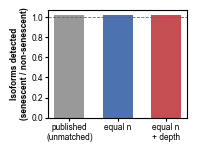

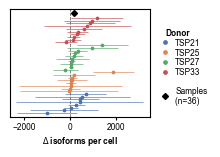

In [37]:
# --- Supp: the control ladder and the n-independent metric, split ----------

# 1: what each control does to the ratio
fig, ax = plt.subplots(figsize=(1.8, 1.4))
labels = ['published\n(unmatched)', 'equal n', 'equal n\n+ depth']
vals = [final['ratio_published'], final['equal_n_ratio_all'],
        final['depth_n_matched_ratio']]
errs = [0,
        float(non_eq['all'].std() / non_eq['all'].mean() * final['equal_n_ratio_all']),
        final['depth_n_matched_sd']]
ax.bar(range(3), vals, yerr=errs, color=['0.6', NON_COLOR, SEN_COLOR],
       width=0.62, error_kw={'lw': 0.6})
ax.axhline(1, color='0.4', lw=0.6, ls='--')
ax.set_xticks(range(3))
ax.set_xticklabels(labels)
ax.set_ylabel('Isoforms detected\n(senescent / non-senescent)')
# ax.set_title('Effect of each control', pad=PANEL_TITLE_PAD)
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath('06_09_supp_control_ladder.pdf'), bbox_inches='tight',
            dpi=300)
plt.show()

# 2: isoforms per cell -- a metric that does not depend on group size
fig, ax = plt.subplots(figsize=(1.8, 1.4))
d_ok = ok.sort_values(['donor', 'effect']).reset_index(drop=True)
donors = sorted(d_ok['donor'].unique())
cmap = {d: DONOR_PALETTE[i % len(DONOR_PALETTE)] for i, d in enumerate(donors)}
for i, r in d_ok.iterrows():
    ax.errorbar(r['effect'], i, xerr=1.96 * r['se'], fmt='o', ms=1.7, lw=0.45,
                color=cmap[r['donor']], zorder=2)
ax.axvline(0, color='0.4', lw=0.6, ls='--', zorder=1)
y_t = len(d_ok) + 1.0
ax.errorbar([flat['effect']], [y_t],
            xerr=[[flat['effect'] - flat['ci_low']],
                  [flat['ci_high'] - flat['effect']]],
            fmt='D', ms=3.0, lw=1.0, color='k', ecolor='k', zorder=3)
# Pooled marker named in the LEGEND with its value, so the y axis carries
# nothing: it is an arbitrary ranking of samples.
ax.set_yticks([])
ax.set_ylim(-1.5, y_t + 1.2)
ax.set_xlabel('$\\Delta$ isoforms per cell')
# ax.set_title('n-independent metric', pad=PANEL_TITLE_PAD)
# Donor key: in the combined figure the point colours were never explained --
# tolerable when this sat beside a labelled panel, not when it stands alone.
h = [plt.Line2D([], [], color=cmap[d], marker='o', ls='', ms=2.4, label=d)
     for d in donors]
leg = ax.legend(handles=h, frameon=False, title='Donor',
                loc=6, bbox_to_anchor = (1.0, 0.6),
                handletextpad=0.2)
leg.get_title().set_fontweight('bold')
ax.add_artist(leg)      # a second ax.legend() would otherwise REPLACE this one

pooled_h = [plt.Line2D([], [], color='k', marker='D', ls='', ms=3.0,
                       label='Samples\n(n=' + str(len(d_ok)) + ') ')]
                             # + format(flat['effect'], '+.1f') + ' ['
                             # + format(flat['ci_low'], '.1f') + ', '
                             # + format(flat['ci_high'], '.1f') + ']')]
ax.legend(handles=pooled_h, frameon=False, loc=6,
          bbox_to_anchor=(1.0, 0.2), ncol=1, handletextpad=0.3)
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath('06_09_supp_isoforms_per_cell_forest.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()


### Does the per-sample effect scale with how many senescent cells the sample yielded?


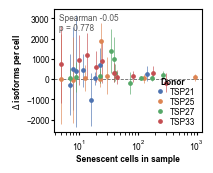

samples plotted: 36
  Spearman(n_senescent, delta)      -0.049   p = 0.7780
  Spearman(tube depth,  delta)      +0.282   p = 0.0955
  Spearman(n_senescent, tube depth) -0.001   p = 0.9952

n_senescent is largely independent of depth, so the first correlation
is interpretable on its own terms.
Whatever it shows, there is no longer a depth-BLOCKED arm to compare
against: the stratified 06_09 was deleted 2026-08-21. This run is
depth-MATCHED, which controls the same confound by a different route.


In [38]:
# --- per-sample effect vs number of senescent cells -------------------------
dvn = ok[['tube_id', 'donor', 'n_group', 'n_ref', 'effect', 'se']].copy()
_tube_depth = (pd.Series(adata.obs[DEPTH].values,
                         index=adata.obs['tube_id'].astype(str).values)
               .groupby(level=0).median())
dvn['tube_median_depth'] = dvn['tube_id'].map(_tube_depth)
dvn.to_csv(OUT + '/06_09_delta_vs_n_senescent.csv', index=False)

rho_n = stats.spearmanr(dvn.n_group, dvn.effect)
rho_d = stats.spearmanr(dvn.tube_median_depth, dvn.effect)
rho_nd = stats.spearmanr(dvn.n_group, dvn.tube_median_depth)

fig, ax = plt.subplots(figsize=(1.9, 1.6))
_dl = sorted(dvn.donor.unique())
_cm = {d: DONOR_PALETTE[i % len(DONOR_PALETTE)] for i, d in enumerate(_dl)}
ax.axhline(0, color='0.4', lw=0.6, ls='--', zorder=1)
for d in _dl:
    s_ = dvn[dvn.donor == d]
    ax.errorbar(s_.n_group, s_.effect, yerr=1.96 * s_.se, fmt='o', ms=2.4,
                lw=0.45, color=_cm[d], ecolor=_cm[d], zorder=2)
ax.set_xscale('log')
ax.set_xlabel('Senescent cells in sample')
ax.set_ylabel('$\\Delta$ isoforms per cell')
ax.annotate('Spearman ' + format(rho_n[0], '+.2f')
            + '\np = ' + format(rho_n[1], '.3f'),
            xy=(0.03, 0.97), xycoords='axes fraction', ha='left', va='top',
            fontsize=6, color='0.35')
h = [plt.Line2D([], [], color=_cm[d], marker='o', ls='', ms=2.4, label=d)
     for d in _dl]
leg = ax.legend(handles=h, frameon=False, title='Donor', loc='lower right',
                handletextpad=0.2)
leg.get_title().set_fontweight('bold')
ax.tick_params(length=TICK_LEN, pad=TICK_LABEL_PAD)
fig.savefig(figpath('06_09_supp_delta_vs_n_senescent.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()

print(f'samples plotted: {len(dvn)}')
print(f'  Spearman(n_senescent, delta)      {rho_n[0]:+.3f}   p = {rho_n[1]:.4f}')
print(f'  Spearman(tube depth,  delta)      {rho_d[0]:+.3f}   p = {rho_d[1]:.4f}')
print(f'  Spearman(n_senescent, tube depth) {rho_nd[0]:+.3f}   p = {rho_nd[1]:.4f}')
print()
if abs(rho_nd[0]) > 0.4:
    print('n_senescent TRACKS DEPTH strongly, so the first correlation cannot be')
    print('read as a dose-response: recovery and depth are the same axis here.')
else:
    print('n_senescent is largely independent of depth, so the first correlation')
    print('is interpretable on its own terms.')
print('Whatever it shows, there is no longer a depth-BLOCKED arm to compare')
print('against: the stratified 06_09 was deleted 2026-08-21. This run is')
print('depth-MATCHED, which controls the same confound by a different route.')
final['delta_vs_nsen_rho'] = float(rho_n[0])
final['delta_vs_nsen_p'] = float(rho_n[1])
final['delta_vs_depth_rho'] = float(rho_d[0])
final['nsen_vs_depth_rho'] = float(rho_nd[0])


## 8. Numbers and text for the manuscript


In [39]:
pd.Series(final).to_csv(OUT + '/06_09_final_numbers.csv', header=['value'])
